<a href="https://colab.research.google.com/github/aleexrtt/ProyectoFinal/blob/main/Proyecto_de_la_clase_de_modelaci%C3%B3n_del_aprendizaje_con_inteligencia_artificial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Price Prediction
## Proyecto final Modelación del aprendizaje con inteligencia artificial
### Diego Zermeño Viramontes | A01611907
### Jesús Higuera Alanís | A01708955
### Luis Alejandro Ruiz Trejo | A01613115
### Ximena González González | A01708366
TEST

El objetivo del siguiente proyecto por medio de técnicas de Machine Learning predecir el precio de cierre ajustado del día siguiente de un activo financiero, utilizando datos históricos obtenidos de Kaggle ([Dataset](https://www.kaggle.com/datasets/suruchiarora/yahoo-finance-dataset-2018-2023)), el dataset tiene a autor a Suruchi Arora, y tiene como propoósito  comprender, identificar patrones y estrategias financieras. Gracias a esto el usuario *_hamid_sadeghi_1*, [Proyecto de Kaggle ](https://www.kaggle.com/code/hamidsadeghi1/yahoo-finance-stock-market-prediction) utilizo el dataset donde utiliza LSTM para predecir, debido al poco conocimiento que se tienen en las Long Short-Term Memory, se decidio realizarlo por medio de árboles de decisión, ensambles como Random Forest y un modelo base de referencia basado en referencia bayesiana.

Dentro de este proyecto el principal problema es que debido al contexto financiero predecir precios dentro de la bolsa de valores es bastante complejo debido a la alta volatilidad del mercado, influencia de factores externos y presencia de ruido en los datos.

Por otro lado, por medio de modelos de aprendizaje automático es posible identificar patrones históricos y relaciones entre variables como el precio de apertura, su precio máximo, precio mínimo, precio de cierre ajustado y el volumen de operaciones.


Para dar más contexto dentro de las técnicas a utilizar, los árboles de decisión según Ledezma (2026), un árbol de decisión es un modelo de aprendizaje supervisado que se utiliza para problemas de clasificación y regresión teniendo una estructura jerárquica que divide los datos en nodos basándose en las variables que maximizan la homogeneidad de los grupos resultantes.

Por otro lado existen los Random Forest, según Ledezma (2026), es un método de aprendizaje conjunto (ensemble learning) que construye múltiples árboles de decisión durante el entrenamiento. Cada árbol se entrena con una muestra aleatoria de los datos mediante una técnica llama Bootstrap y la predicción final se obtiene por votación en mayoría de clasificación o promedio en regresión, este tiene ventaja ante los árboles de decisión, esto son:

1.   Reducción de sobreajuste
2.   Mayor estabilidad
3.   Versatilidad de las variables

Finalmente, el modelo basado en la inferencia bayesiana según Noreña (s.f.), puede ser definida como un enfoque estadístico que permite estimar y actualizar la incertidumbre de los datos a medida que vamos obteniendo información, como fue visto en clase la probabilidad bayesiana permite actualizar y calcular lo que se conoce de algo observado, por lo tanto, trata los parámetros o variables desconocidas como variables aleatorias describiéndolas en términos de distribuciones de probabilidad.
Donde se basa en el Teorema de Bayes el cual establece una probabilidad posterior se relaciona con una probabilidad previa y la verosimilitud de lo observado, permitiendo actualizar continuamente la información.





Para la siguiente modelo se utilizaran las siguientes librerias:

#Librerias utilizadas

In [ ]:

import pandas as pd #Manipulación de datos y análisis de ellos.
import numpy as np #Calculo númerico
import matplotlib.pyplot as plt #Visualización de gráficos

from sklearn.tree import DecisionTreeRegressor, plot_tree #Árbol de decisión mediante Sklearn
from sklearn.ensemble import RandomForestRegressor #Random Forest por medio de Sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score #Métricas necesarias para la implementación
from sklearn.naive_bayes import GaussianNB #Modelo de inferencia bayesiana



El dataset fue obtenido en Yahoo Finance, contiene variables relacionadas con el comportamiento del mercado durante el 1ero Mayo del 2018 hasta el 28 de Abril del año 2023, las variables del conjunto de datos son:


| Variable | Descripción |
| :--- | :---:
| Date| Fecha de registro|
| Open| Precio de apertura del activo en ese día |
| High| Precio máximo alcanzado durante ese día|
| Low | Precio mínimo alcanzado durante el día|
| Close| Precio de cierre de la acción |
| Adj Close| Precio de cierre ajustado |
| Volume| Volumen de operaciones |

La variable *Adj Close* es la variable de nuestro interés debido a que es el precio de cierre ajustado esta considera dividendos, splits y otros ajustes financieros. Por esta razón, se suele utilizar como una medida estable y representativa del valor real a lo largo del tiempo


#Parte 1: Carga, Limpieza y Exploración de Datos

In [ ]:
df = pd.read_excel("yahoo_data.xlsx")

# Renombramos columnas para evitar caracteres especiales que son los "*" de la base de datos
df.columns = ["Date", "Open", "High", "Low", "Close", "Adj_Close", "Volume"]

# Convertimos la fecha y ordenamos cronológicamente (más antiguo primero)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

#Vemos la vista general del conjunto de datos
print("Vista general del dataset")
print(df.head())
print(f"\nForma del dataset: {df.shape}")
print(f"\nRango de fechas: {df['Date'].min().date()} → {df['Date'].max().date()}")
print("\nEstadísticas descriptivas:")
print(df.describe())


Vista general del dataset
        Date      Open      High       Low     Close  Adj_Close     Volume
0 2018-05-01  24117.29  24117.29  23808.19  24099.05   24099.05  380070000
1 2018-05-02  24097.63  24185.52  23886.30  23924.98   23924.98  385350000
2 2018-05-03  23836.23  23996.15  23531.31  23930.15   23930.15  389240000
3 2018-05-04  23865.22  24333.35  23778.87  24262.51   24262.51  329480000
4 2018-05-07  24317.66  24479.45  24263.42  24357.32   24357.32  307670000

Forma del dataset: (1258, 7)

Rango de fechas: 2018-05-01 → 2023-04-28

Estadísticas descriptivas:
                                Date          Open          High  \
count                           1258   1258.000000   1258.000000   
mean   2020-10-28 09:39:12.305246464  29595.823045  29776.945739   
min              2018-05-01 00:00:00  19028.360000  19121.010000   
25%              2019-07-31 06:00:00  26041.267500  26163.155000   
50%              2020-10-27 12:00:00  29201.410000  29335.685000   
75%             

In [ ]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nNúmero de filas duplicadas:")
print(df.duplicated().sum())

print("\nTipos de datos:")
print(df.dtypes)


Valores nulos por columna:
Date         0
Open         0
High         0
Low          0
Close        0
Adj_Close    0
Volume       0
dtype: int64

Número de filas duplicadas:
0

Tipos de datos:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj_Close           float64
Volume                int64
dtype: object


Antes de realizar cualquier predicción, se observo la calidad de los datos, fue posible identificar que no hay valores nulos en cada columna, por lo que no fue necesario eliminar filas ni técnicas para imputar datos. Por otro lado, no existen datos duplicados por lo que el dataset funciona perfectamente para realizar las predicciones. Igualmente, las columnas tuvieron que ser renombradas para evitar errores en el codigo.
Con esto, la desviación estándar que muestra la variablilidad en los datos, en este caso se obtuvo dispersión natural en un mercado financiero.

Como nota, el *Adj_Close* y *Close* son iguales en todo el dataset por lo que se seleccionara para el entrenamiento la variable *Close*
**Amigos Podríamos agregar aquí un diagrama de dispersión o uno que muestre como se comportan los datos para que el proyecto se vea mejor**

# Parte 2 Objetivo y Features

El objetivo del proyecto es predecir el precio de cierre ajustado al dia Siguiente por lo que se crea una variable llamada **Objetivo** desplazando la variable *Adj-Close* un día hacia atrás. Por otro lado, para realizar las predicciones es necesario variables de entrada y una salida. En este caso, las variables de entrada corresponden a los datos financieros del dia actual *"Open", "High", "Low", "Adj_Close", "Volume"* y deben estimar el precio de cierre ajustado al dia siguiente. Mientras que, nuestra variable objetivo o de salida es *AdjClose* la que predice el precio de cierre ajustado al dia siguiente

In [ ]:
# Nuestro objetivo es predecir el precio de cierre ajustado del día SIGUIENTE
# Creamos la columna desplazando Adj_Close un día hacia atrás
df["Target"] = df["Adj_Close"].shift(-1)

# Eliminamos la última fila (no tiene día siguiente)
df = df.dropna().reset_index(drop=True)

# Features: columnas OHLCV del día actual
features = ["Open", "High", "Low","Adj_Close", "Volume"]

X = df[features]
y = df["Target"]

print("\n Variables del modelo")
print(f"Features (X): {features}")
print(f"Target  (y): Adj_Close del día siguiente")
print(f"Total de muestras: {len(X)}")




 Variables del modelo
Features (X): ['Open', 'High', 'Low', 'Adj_Close', 'Volume']
Target  (y): Adj_Close del día siguiente
Total de muestras: 1257


Dentro del uso de IA ChatGPT recomendo usar

In [ ]:
# ============================================================
# 3. DIVISIÓN EN ENTRENAMIENTO Y PRUEBA (80/20 cronológico)
# ============================================================

# Para series de tiempo NO usamos shuffle; respetamos el orden cronológico
split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("\n División de datos")
print(f"Entrenamiento: {len(X_train)} muestras "
      f"({df['Date'].iloc[0].date()} → {df['Date'].iloc[split_index-1].date()})")
print(f"Prueba:        {len(X_test)} muestras "
      f"({df['Date'].iloc[split_index].date()} → {df['Date'].iloc[-1].date()})")


 División de datos
Entrenamiento: 1005 muestras (2018-05-01 → 2022-04-26)
Prueba:        252 muestras (2022-04-27 → 2023-04-27)


In [ ]:
# ============================================================
# 4. MODELO 1: DECISION TREE REGRESSOR
# ============================================================

dt_model = DecisionTreeRegressor(
    max_depth=5,           # limitamos profundidad para evitar overfitting
    criterion="squared_error",
    random_state=42,

)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("\n Resultados: Decision Tree")
dt_mae  = mean_absolute_error(y_test, dt_pred)
dt_mse  = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2   = r2_score(y_test, dt_pred)

print(f"MAE:  {dt_mae:,.2f}")
print(f"MSE:  {dt_mse:,.2f}")
print(f"RMSE: {dt_rmse:,.2f}")
print(f"R²:   {dt_r2:.4f}")

TypeError: DecisionTreeRegressor.__init__() got an unexpected keyword argument 'shuffle'

In [ ]:
# ============================================================
# 5. MODELO 2: RANDOM FOREST REGRESSOR
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=100,      # 100 árboles en el bosque
    max_depth=5,           # misma profundidad máxima que el DT para comparar justo
    criterion="squared_error",
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\n Resultados: Random Forest")
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_mse  = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2   = r2_score(y_test, rf_pred)

print(f"MAE:  {rf_mae:,.2f}")
print(f"MSE:  {rf_mse:,.2f}")
print(f"RMSE: {rf_rmse:,.2f}")
print(f"R²:   {rf_r2:.4f}")


 Resultados: Random Forest
MAE:  323.77
MSE:  177,595.90
RMSE: 421.42
R²:   0.9006


In [ ]:
# ============================================================
# 6. TABLA COMPARATIVA DE MÉTRICAS
# ============================================================

print("\n Comparación de modelos")
results = pd.DataFrame({
    "Modelo": ["Decision Tree", "Random Forest"],
    "MAE":    [dt_mae,  rf_mae],
    "MSE":    [dt_mse,  rf_mse],
    "RMSE":   [dt_rmse, rf_rmse],
    "R²":     [dt_r2,   rf_r2]
})
print(results.to_string(index=False))


 Comparación de modelos
       Modelo        MAE           MSE       RMSE       R²
Decision Tree 369.490820 232368.864187 482.046537 0.869896
Random Forest 323.773552 177595.901223 421.421287 0.900564


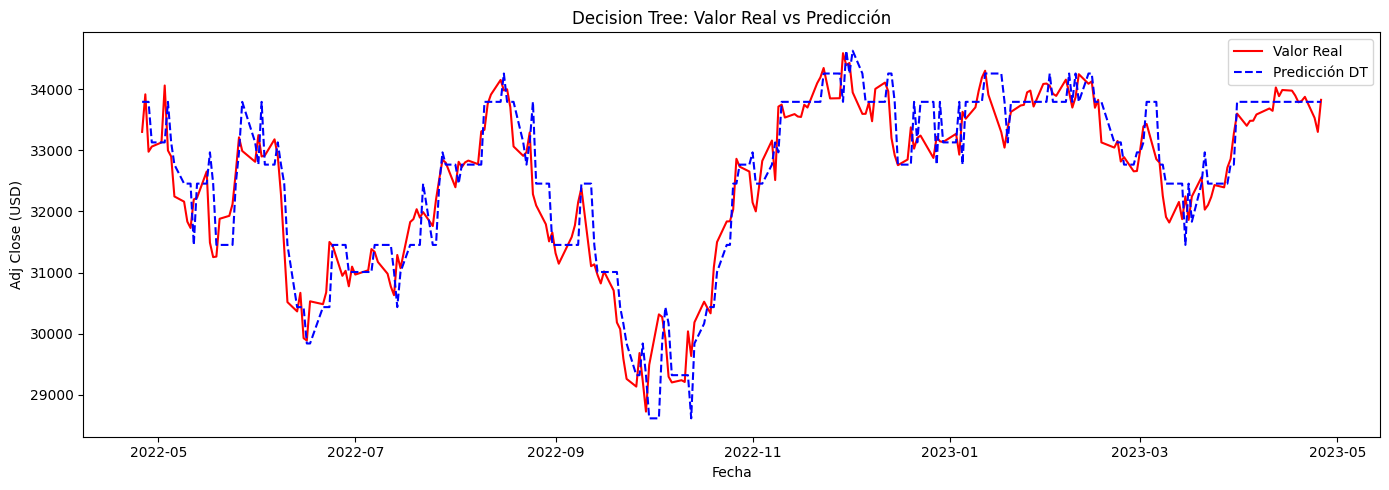

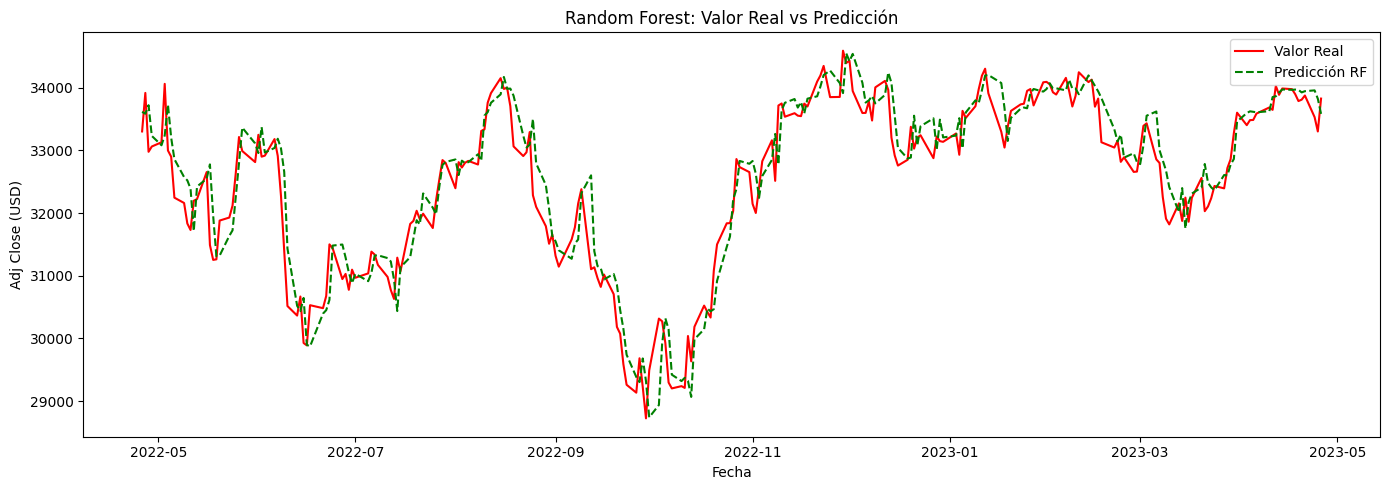

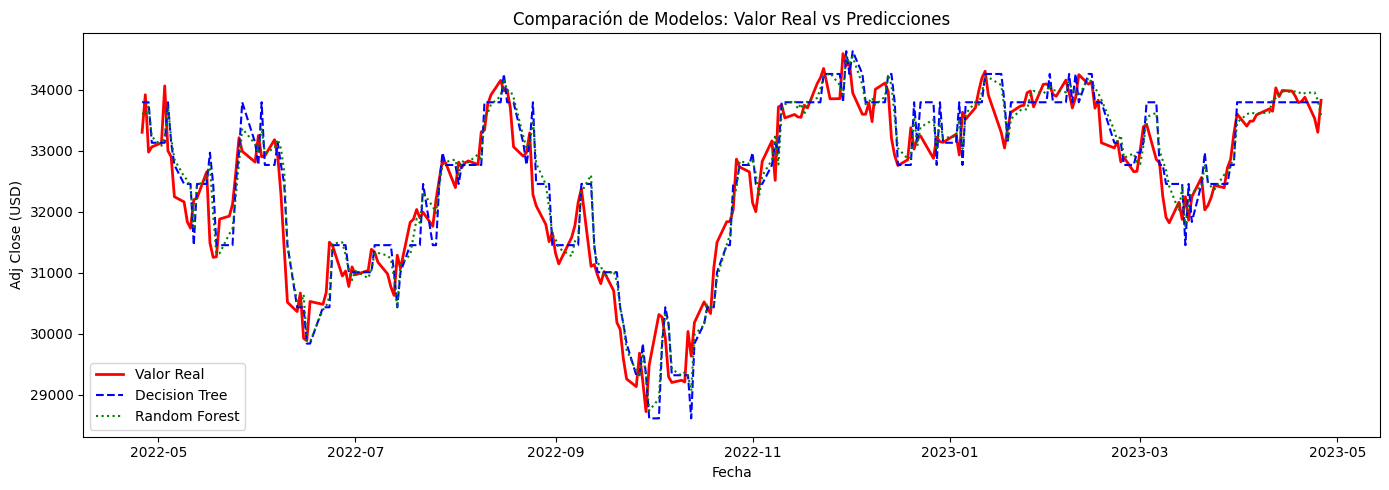

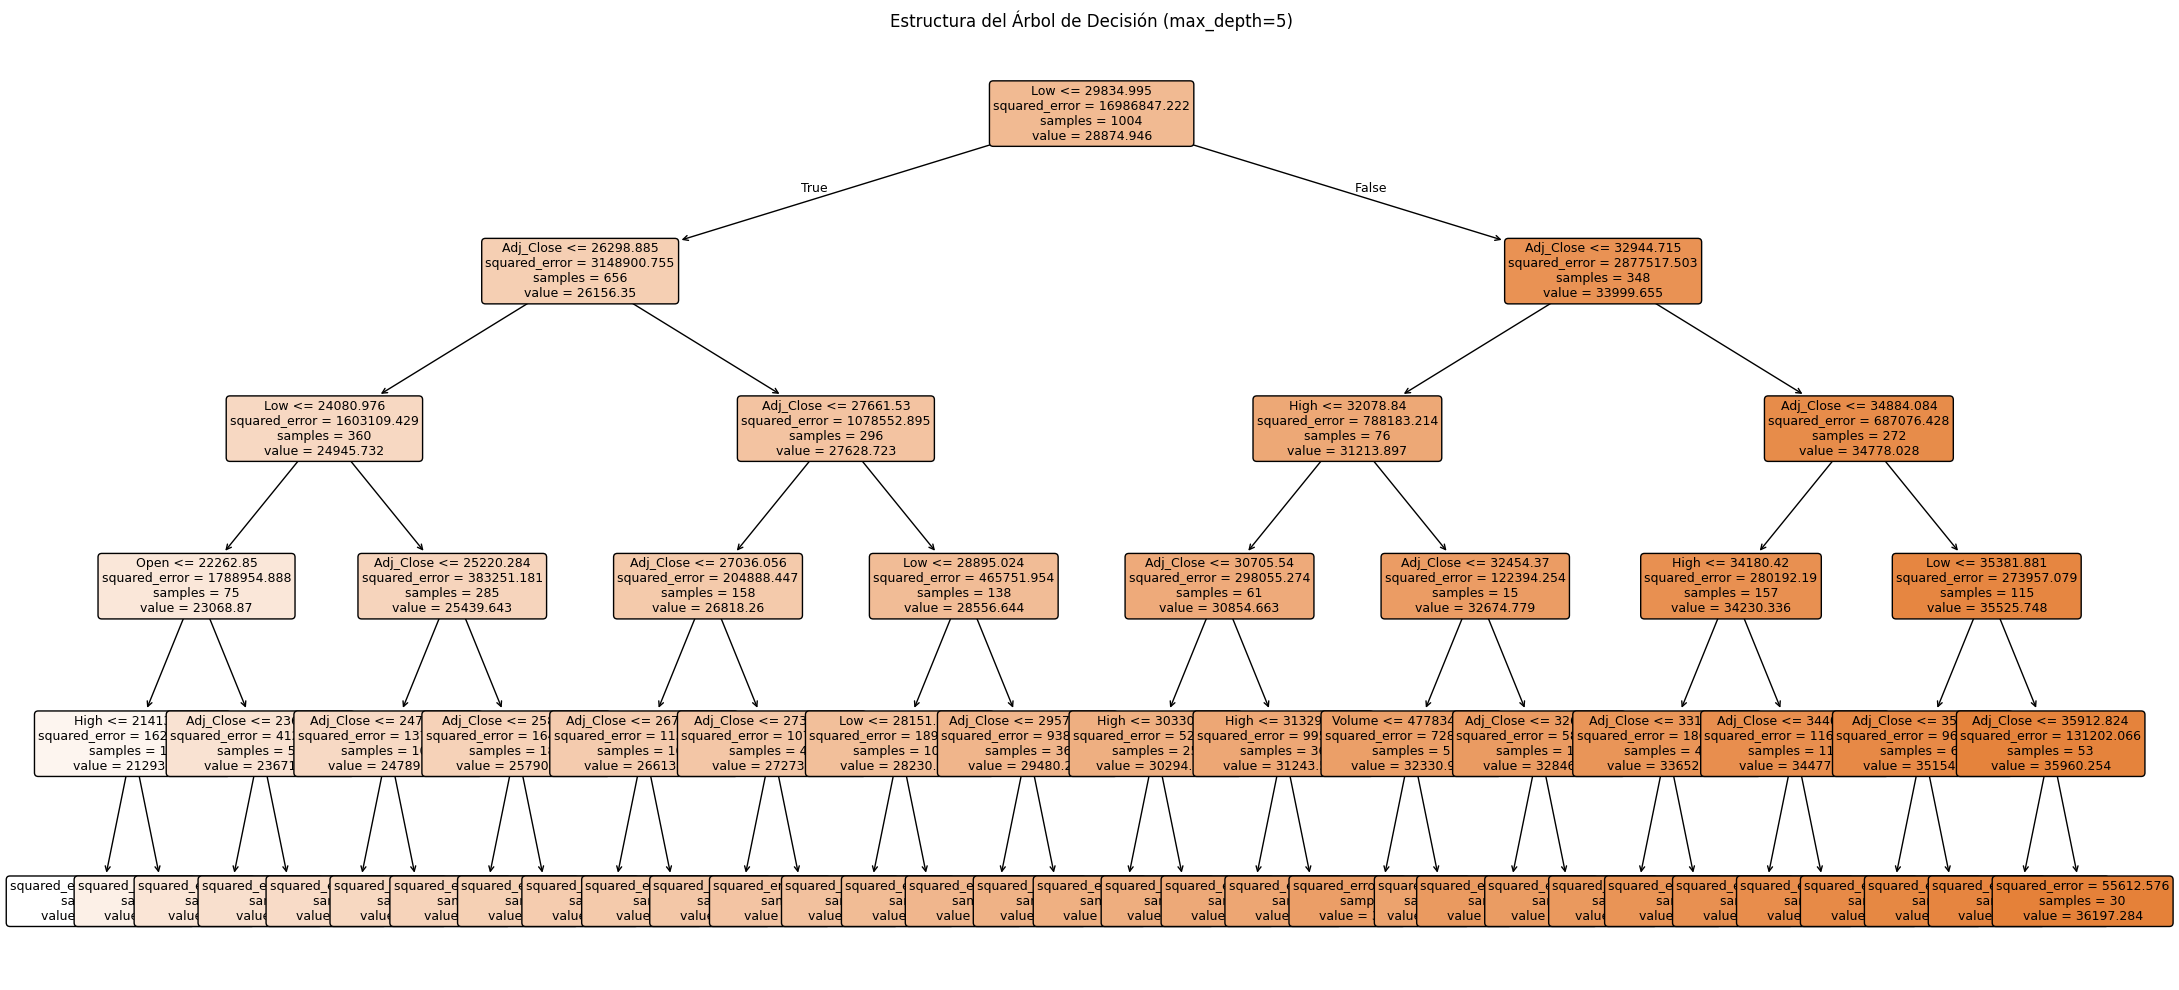

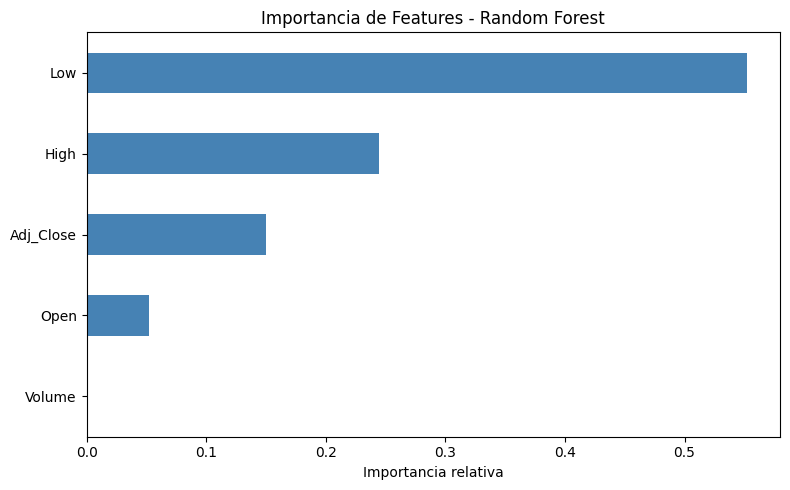

In [ ]:
# ============================================================
# 7. VISUALIZACIONES
# ============================================================

fechas_test = df["Date"].iloc[split_index:].values

# La gráfica 1 compara las predicciones vs el valor real (Decision Tree)
plt.figure(figsize=(14, 5))
plt.plot(fechas_test, y_test.values, label="Valor Real", color="red", linewidth=1.5)
plt.plot(fechas_test, dt_pred,       label="Predicción DT", color="blue", linewidth=1.5, linestyle="--")
plt.title("Decision Tree: Valor Real vs Predicción")
plt.xlabel("Fecha")
plt.ylabel("Adj Close (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# La gráfica 2 compara las predicciones vs el valor real (Random Forest) ---
plt.figure(figsize=(14, 5))
plt.plot(fechas_test, y_test.values, label="Valor Real",      color="red", linewidth=1.5)
plt.plot(fechas_test, rf_pred,       label="Predicción RF",   color="green", linewidth=1.5, linestyle="--")
plt.title("Random Forest: Valor Real vs Predicción")
plt.xlabel("Fecha")
plt.ylabel("Adj Close (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# La gráfica 3 compara ambos modelos juntos
plt.figure(figsize=(14, 5))
plt.plot(fechas_test, y_test.values, label="Valor Real",    color="red",   linewidth=2)
plt.plot(fechas_test, dt_pred,       label="Decision Tree", color="blue",  linewidth=1.5, linestyle="--")
plt.plot(fechas_test, rf_pred,       label="Random Forest", color="green", linewidth=1.5, linestyle=":")
plt.title("Comparación de Modelos: Valor Real vs Predicciones")
plt.xlabel("Fecha")
plt.ylabel("Adj Close (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# La gráfica 4, muestra una visualización del árbol de decisión
plt.figure(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Estructura del Árbol de Decisión (max_depth=5)")
plt.tight_layout()
plt.show()

# La gráfica 5, muestra la importancia de features (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue")
plt.title("Importancia de Features - Random Forest")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()